In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the data
data = pd.read_csv('/data.csv', header=None)
X = data.iloc[:, :2].values  # Features (x1, x2)
y = data.iloc[:, 2].values   # Labels (0 or 1)

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {len(y)}")
print(f"Class 0 samples: {np.sum(y == 0)}, Class 1 samples: {np.sum(y == 1)}")

Dataset shape: (100, 2)
Number of samples: 100
Class 0 samples: 50, Class 1 samples: 50


In [7]:
class PerceptronHeuristic:
    """Perceptron with binary step function (heuristic approach)"""

    def __init__(self, learning_rate=0.01):
        self.learning_rate = learning_rate
        self.weights = None
        self.bias = None
        self.weight_history = []

    def initialize_weights(self, n_features):
        """Initialize weights and bias randomly"""
        np.random.seed(42)
        self.weights = np.random.randn(n_features)
        self.bias = np.random.randn()

    def step_function(self, z):
        """Binary step function: returns 1 if z >= 0, else 0"""
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        """Predict class labels using step function"""
        z = np.dot(X, self.weights) + self.bias
        return self.step_function(z)

    def fit(self, X, y, n_iterations=100):
        """Train the perceptron using heuristic approach"""
        n_samples, n_features = X.shape
        self.initialize_weights(n_features)

        # Store initial weights
        self.weight_history.append((self.weights.copy(), self.bias))

        for iteration in range(n_iterations):
            misclassified = 0

            # Go through each sample
            for idx in range(n_samples):
                xi = X[idx]
                yi = y[idx]

                # Classify the point
                prediction = self.predict(xi.reshape(1, -1))[0]

                # If misclassified, update weights
                if prediction != yi:
                    misclassified += 1

                    if prediction == 0:  # Error = 1 (should be 1, predicted 0)
                        self.bias += self.learning_rate
                        self.weights += self.learning_rate * xi
                    else:  # Error = -1 (should be 0, predicted 1)
                        self.bias -= self.learning_rate
                        self.weights -= self.learning_rate * xi

            # Store weights after each iteration
            self.weight_history.append((self.weights.copy(), self.bias))

            if misclassified == 0:
                print(f"Converged at iteration {iteration + 1}")
                break

        return self.weight_history

    def get_decision_boundary(self, x_range):
        """Calculate y values for decision boundary line"""
        # w1*x1 + w2*x2 + b = 0
        # x2 = -(w1*x1 + b) / w2
        if self.weights[1] != 0:
            return -(self.weights[0] * x_range + self.bias) / self.weights[1]
        else:
            return None


def plot_part1_results(X, y, learning_rate, n_iterations=100):
    """Plot results for Part 1 with different learning rates"""

    perceptron = PerceptronHeuristic(learning_rate=learning_rate)
    weight_history = perceptron.fit(X, y, n_iterations=n_iterations)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot data points
    class_0 = y == 0
    class_1 = y == 1
    ax.scatter(X[class_0, 0], X[class_0, 1], c='red', marker='o', label='Class 0', s=50, edgecolors='black')
    ax.scatter(X[class_1, 0], X[class_1, 1], c='blue', marker='o', label='Class 1', s=50, edgecolors='black')

    # X range for plotting lines
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    x_range = np.array([x_min, x_max])

    # Plot initial decision boundary (red)
    w_init, b_init = weight_history[0]
    if w_init[1] != 0:
        y_init = -(w_init[0] * x_range + b_init) / w_init[1]
        ax.plot(x_range, y_init, 'r-', linewidth=2, label='Initial boundary')

    # Plot intermediate boundaries (green dashed)
    for i in range(1, len(weight_history) - 1):
        w, b = weight_history[i]
        if w[1] != 0:
            y_line = -(w[0] * x_range + b) / w[1]
            ax.plot(x_range, y_line, 'g--', linewidth=0.5, alpha=0.3)

    # Plot final decision boundary (black)
    w_final, b_final = weight_history[-1]
    if w_final[1] != 0:
        y_final = -(w_final[0] * x_range + b_final) / w_final[1]
        ax.plot(x_range, y_final, 'k-', linewidth=2, label='Final boundary')

    # Add green dashed to legend (just one representative line)
    ax.plot([], [], 'g--', linewidth=1, label='Intermediate boundaries')

    ax.set_xlabel('x₁', fontsize=12)
    ax.set_ylabel('x₂', fontsize=12)
    ax.set_title(f'Solution boundary (Learning rate = {learning_rate}, Iterations = {len(weight_history)-1})',
                 fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(X[:, 1].min() - 0.1, X[:, 1].max() + 0.1)

    plt.tight_layout()
    plt.savefig(f'/home/claude/part1_lr_{learning_rate}.png', dpi=300, bbox_inches='tight')
    plt.close()

    return len(weight_history) - 1  # Return number of iterations

In [8]:
class PerceptronGradientDescent:
    """Perceptron with sigmoid activation and gradient descent"""

    def __init__(self, learning_rate=0.1):
        self.learning_rate = learning_rate
        self.weights = None
        self.bias = None
        self.weight_history = []
        self.loss_history = []

    def initialize_weights(self, n_features):
        """Initialize weights and bias randomly"""
        np.random.seed(42)
        self.weights = np.random.randn(n_features)
        self.bias = np.random.randn()

    def sigmoid(self, z):
        """Sigmoid activation function"""
        # Clip values to prevent overflow
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def predict_proba(self, X):
        """Predict probabilities using sigmoid"""
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)

    def predict(self, X):
        """Predict class labels (threshold at 0.5)"""
        return (self.predict_proba(X) >= 0.5).astype(int)

    def log_loss(self, y_true, y_pred_proba):
        """Calculate log loss (binary cross-entropy)"""
        # Clip predictions to avoid log(0)
        epsilon = 1e-15
        y_pred_proba = np.clip(y_pred_proba, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))

    def fit(self, X, y, n_epochs=100):
        """Train the perceptron using gradient descent"""
        n_samples, n_features = X.shape
        self.initialize_weights(n_features)

        # Store initial weights
        self.weight_history.append((self.weights.copy(), self.bias))

        for epoch in range(n_epochs):
            # Forward pass for all samples
            y_pred_proba = self.predict_proba(X)

            # Calculate loss
            loss = self.log_loss(y, y_pred_proba)
            self.loss_history.append(loss)

            # Calculate gradients (average over all samples)
            error = y_pred_proba - y  # Shape: (n_samples,)

            # Gradient descent update
            dw = np.dot(X.T, error) / n_samples  # Shape: (n_features,)
            db = np.mean(error)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Store weights after each epoch
            self.weight_history.append((self.weights.copy(), self.bias))

        return self.weight_history, self.loss_history


def plot_part2_results(X, y, learning_rate, n_epochs=100):
    """Plot results for Part 2 with gradient descent"""

    perceptron = PerceptronGradientDescent(learning_rate=learning_rate)
    weight_history, loss_history = perceptron.fit(X, y, n_epochs=n_epochs)

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # ========== Left plot: Decision boundary ==========
    # Plot data points
    class_0 = y == 0
    class_1 = y == 1
    ax1.scatter(X[class_0, 0], X[class_0, 1], c='red', marker='o', label='Class 0', s=50, edgecolors='black')
    ax1.scatter(X[class_1, 0], X[class_1, 1], c='blue', marker='o', label='Class 1', s=50, edgecolors='black')

    # X range for plotting lines
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    x_range = np.array([x_min, x_max])

    # Plot initial decision boundary (red)
    w_init, b_init = weight_history[0]
    if w_init[1] != 0:
        y_init = -(w_init[0] * x_range + b_init) / w_init[1]
        ax1.plot(x_range, y_init, 'r-', linewidth=2, label='Initial boundary')

    # Plot intermediate boundaries (green dashed) - every 10 epochs
    for i in range(10, len(weight_history) - 1, 10):
        w, b = weight_history[i]
        if w[1] != 0:
            y_line = -(w[0] * x_range + b) / w[1]
            ax1.plot(x_range, y_line, 'g--', linewidth=0.5, alpha=0.3)

    # Plot final decision boundary (blue/black)
    w_final, b_final = weight_history[-1]
    if w_final[1] != 0:
        y_final = -(w_final[0] * x_range + b_final) / w_final[1]
        ax1.plot(x_range, y_final, 'b-', linewidth=2.5, label='Final boundary')

    # Add green dashed to legend
    ax1.plot([], [], 'g--', linewidth=1, label='Intermediate boundaries')

    ax1.set_xlabel('x₁', fontsize=12)
    ax1.set_ylabel('x₂', fontsize=12)
    ax1.set_title('Solution boundary', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(X[:, 1].min() - 0.1, X[:, 1].max() + 0.1)

    # ========== Right plot: Error curve ==========
    epochs = range(len(loss_history))
    ax2.plot(epochs, loss_history, 'b-', linewidth=2)
    ax2.set_xlabel('Number of epochs', fontsize=12)
    ax2.set_ylabel('Error (Log Loss)', fontsize=12)
    ax2.set_title('Error Plot', fontsize=14)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'/home/claude/part2_lr_{learning_rate}_epochs_{n_epochs}.png', dpi=300, bbox_inches='tight')
    plt.close()

    return loss_history[-1]  # Return final loss




PART 1: HEURISTIC APPROACH WITH STEP FUNCTION

Testing with learning rate = 0.01


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/part1_lr_0.01.png'

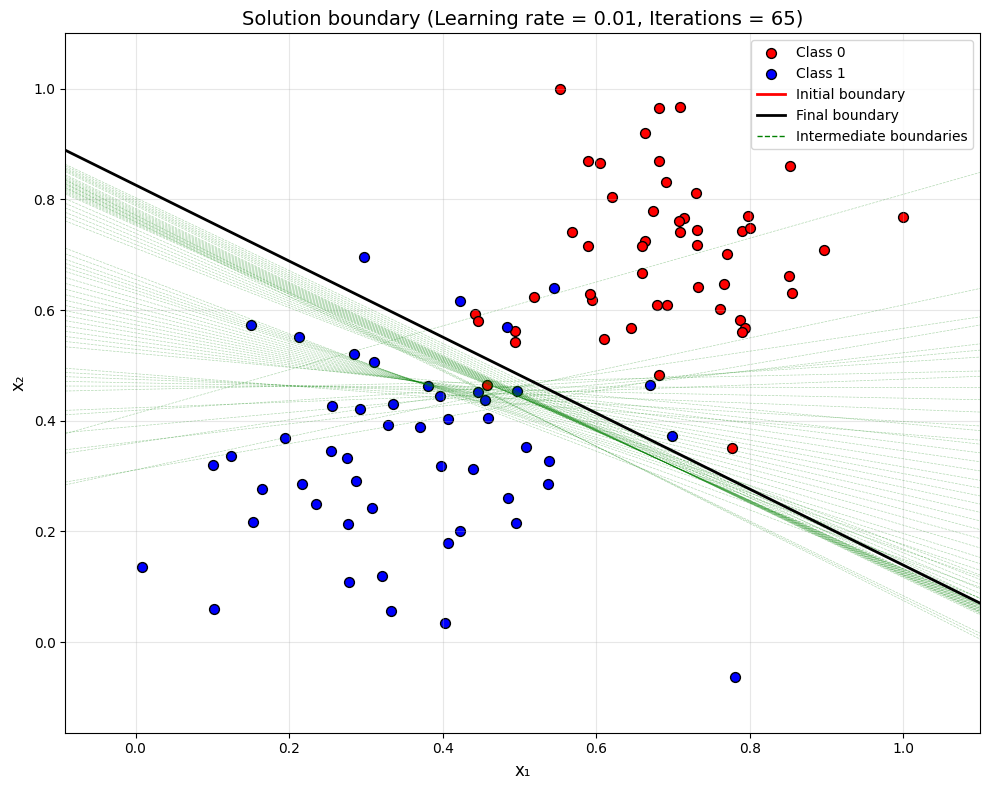

In [9]:
print("\n" + "="*70)
print("PART 1: HEURISTIC APPROACH WITH STEP FUNCTION")
print("="*70)

learning_rates_part1 = [0.01, 0.1, 1.0]
n_iterations = 65

for lr in learning_rates_part1:
    print(f"\nTesting with learning rate = {lr}")
    iterations = plot_part1_results(X, y, learning_rate=lr, n_iterations=n_iterations)
    print(f"Completed in {iterations} iterations")

print("\n" + "="*70)
print("PART 2: GRADIENT DESCENT WITH SIGMOID")
print("="*70)

learning_rates_part2 = [0.1, 0.5, 1.0]
n_epochs = 100

for lr in learning_rates_part2:
    print(f"\nTesting with learning rate = {lr}")
    final_loss = plot_part2_results(X, y, learning_rate=lr, n_epochs=n_epochs)
    print(f"Final log loss: {final_loss:.6f}")

print("\n" + "="*70)
print("All experiments completed! Plots saved.")
print("="*70)